# 1. Load the clean data

In [1]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,FireplaceYN_missing,PoolPrivateYN_missing,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,1,0,890000.0,34.264692,-117.221040,3000.0,287A - Arrowhead Woods,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,1,0,0
1,0,0,6995.0,34.261268,-119.272458,1386.0,VC23 - Ventura Beach S. of Ventura River to S.C.,Ventura,2.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,0,0,1
2,1,0,865000.0,33.906058,-117.777782,1442.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,1,0,0
3,0,0,875000.0,37.705919,-122.059421,1086.0,Unknown,Alameda,4.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,1,0,0
4,0,0,769645.0,37.986319,-122.001549,1608.0,Unknown,Contra Costa,0.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188840,1,0,865000.0,34.242304,-116.802871,2166.0,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,1,0,0
188841,1,1,4000.0,33.701018,-116.292460,2957.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,0,0,1
188842,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,1,0,1,0,0,0,1,0,0,0
188843,0,0,595000.0,37.824500,-122.281570,2502.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,1,0,0


# 2. Test train valid split¶

In [2]:
X=12 # past  month
months = sorted(data_clean["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=data_clean[data_clean['date_ym'].isin(months[-X:-1])]
data_test=data_clean[data_clean['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

2025-07-01    15856
2026-04-01    15657
2026-05-01    15615
2025-10-01    15524
2025-08-01    15461
2025-09-01    15159
2026-03-01    15077
2025-12-01    13478
2025-11-01    12674
2026-02-01    11879
2026-01-01    10756
Name: date_ym, dtype: int64
2026-06-01    16516
Name: date_ym, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 157136 entries, 15193 to 172328
Data columns (total 37 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ViewYN                           157136 non-null  int64  
 1   PoolPrivateYN                    157136 non-null  int64  
 2   ClosePrice                       157136 non-null  float64
 3   Latitude                         157136 non-null  float64
 4   Longitude                        157136 non-null  float64
 5   LivingArea                       157136 non-null  float64
 6   MLSAreaMajor                     157136 non-null  object 
 7   CountyOrParish   

In [3]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16516 entries, 172329 to 188844
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ViewYN                           16516 non-null  int64  
 1   PoolPrivateYN                    16516 non-null  int64  
 2   ClosePrice                       16516 non-null  float64
 3   Latitude                         16516 non-null  float64
 4   Longitude                        16516 non-null  float64
 5   LivingArea                       16516 non-null  float64
 6   MLSAreaMajor                     16516 non-null  object 
 7   CountyOrParish                   16516 non-null  object 
 8   ParkingTotal                     16516 non-null  float64
 9   PropertySubType                  16516 non-null  object 
 10  LotSizeAcres                     16516 non-null  float64
 11  YearBuilt                        16516 non-null  float64
 12  StreetNumber

In [4]:
# remove some outliers from train dataset
lower=data_train["ClosePrice"].quantile(0.005)
upper=data_train["ClosePrice"].quantile(0.995)
data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

In [5]:
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# keep the cols consistently
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\AppData\Local\Temp\ipykernel_8232\4208753145.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\4208753145.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\4208753145.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [6]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

# 3. Train a Regression model and Evaluate the result

In [7]:
results = []

## 3.1 ElasticNet - Baseline model

In [8]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.002e+16, tolerance: 8.825e+12
  model = cd_fast.enet_coordinate_descent(


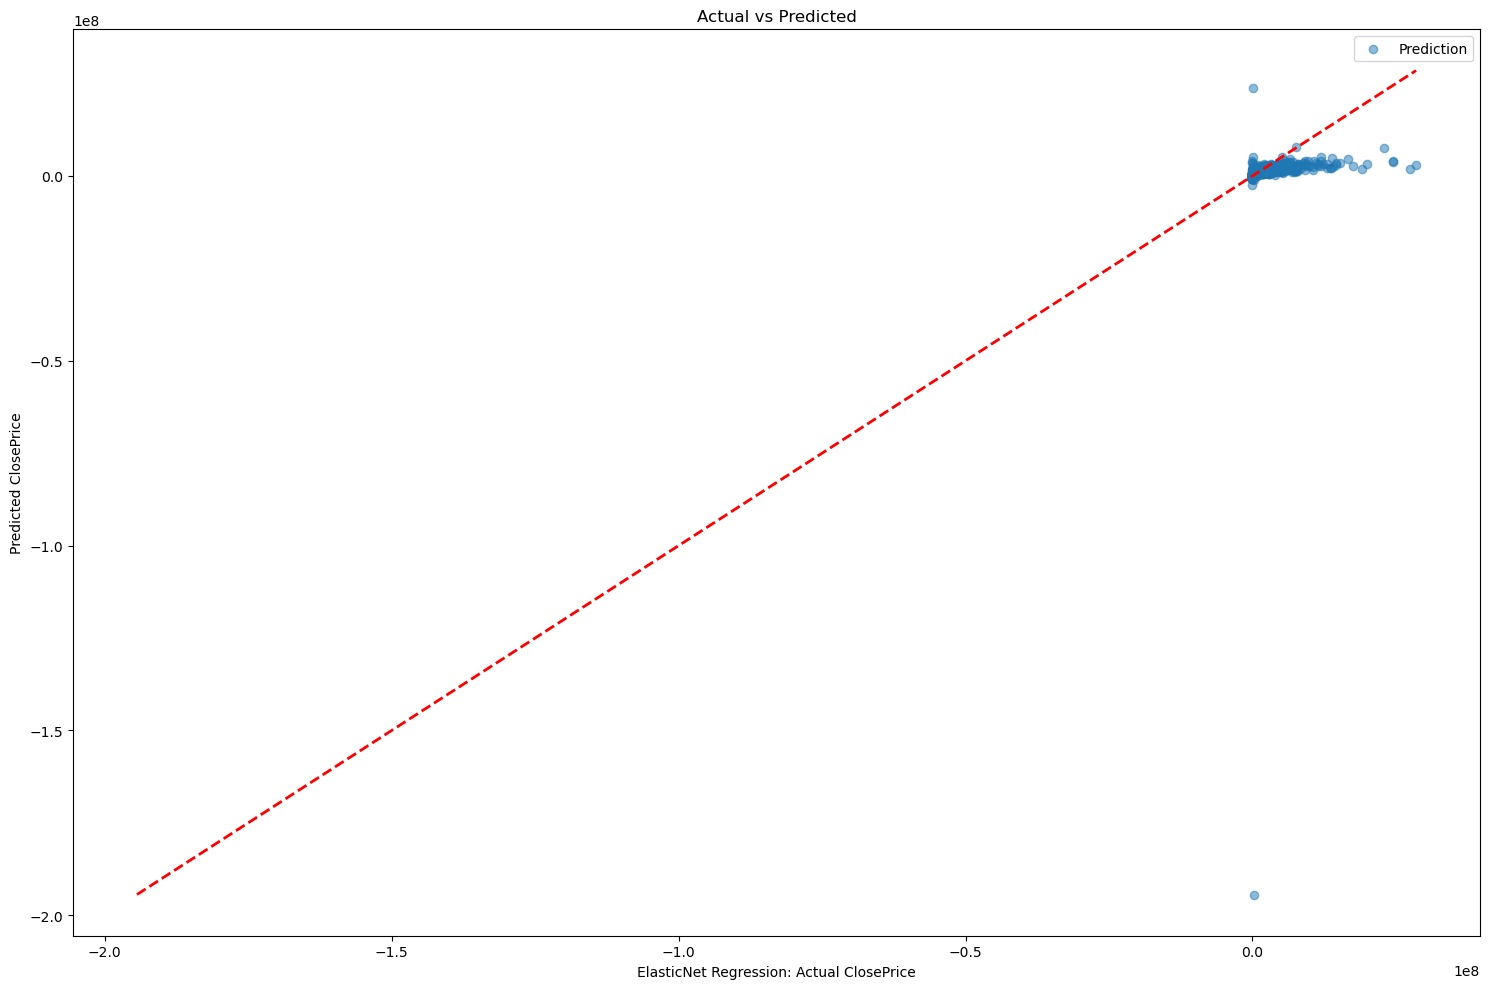

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("ElasticNet Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [10]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"ElasticNet Regression- Baseline model",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 35.29%
MAPE : 16.0794
R²   : -1.5174
MAE  : 360781.7189
MSE  : 2964894025687.3335
RMSE : 1721886.7633


## 3.2 Decision Tree Regressor

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=10,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

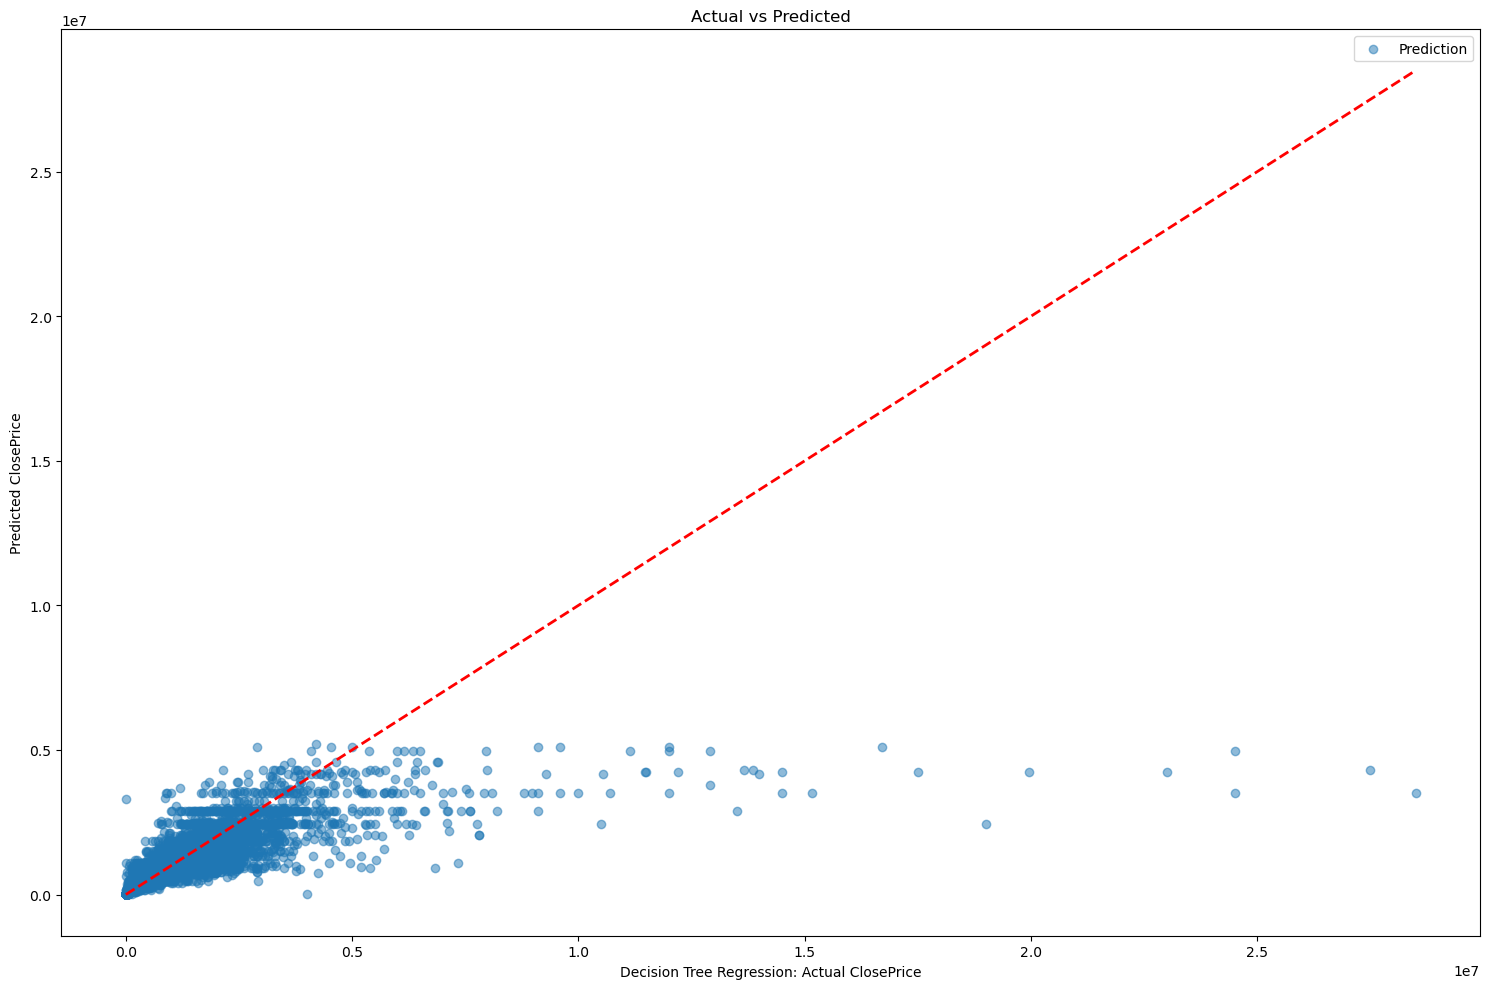

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Decision Tree Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [13]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Decision Tree Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 17.68%
MAPE : 0.3976
R²   : 0.5935
MAE  : 230856.3088
MSE  : 478731608179.4233
RMSE : 691904.3346


In [14]:
print(model.score(X_train, y_train))

0.797527857296263


### Feature importance

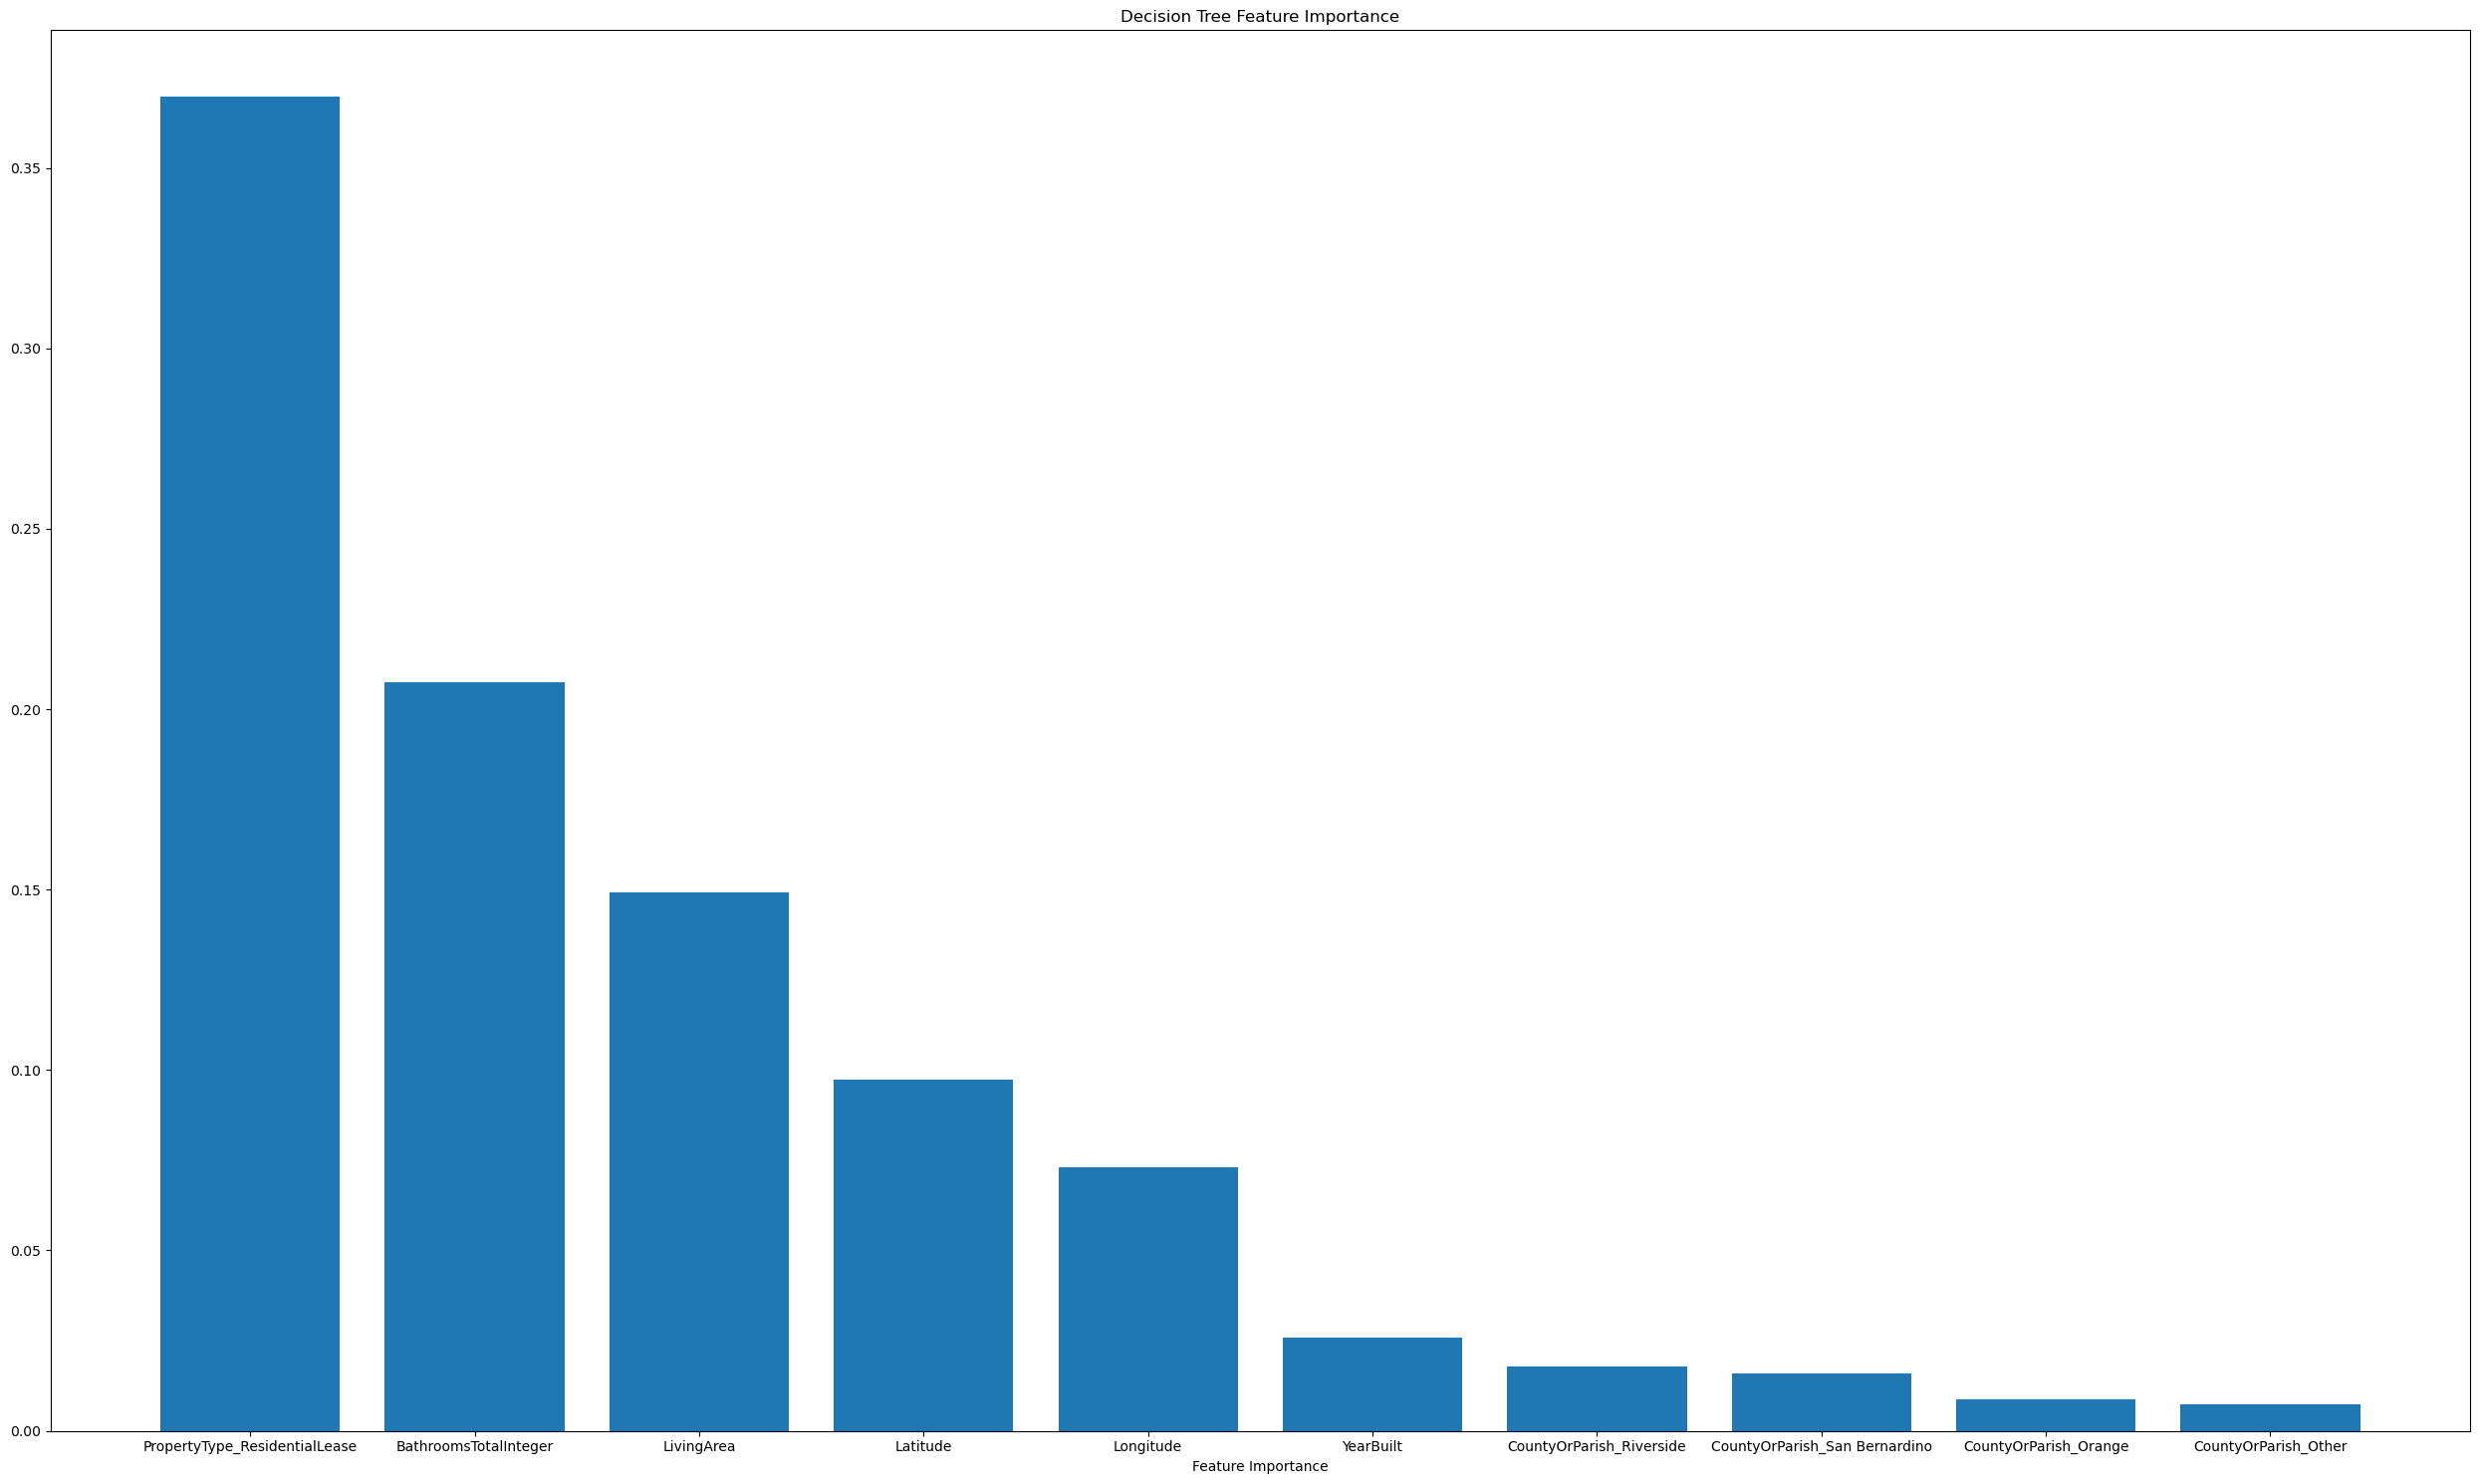

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

## 3.3 Random Forest Regressor

In [16]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

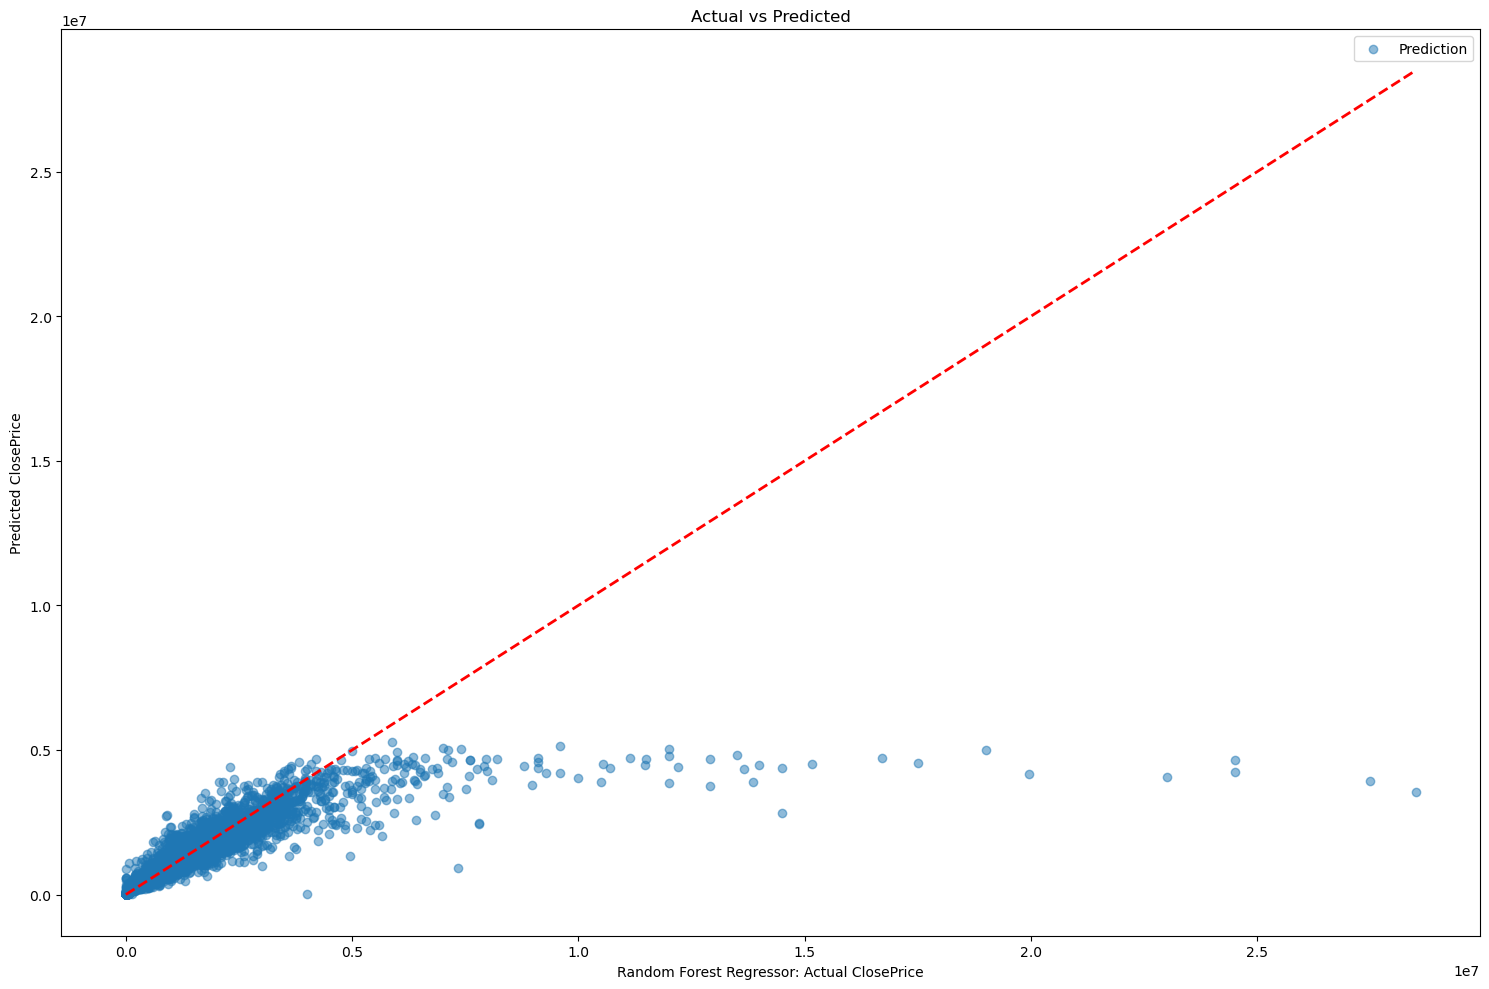

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Random Forest Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 8.22%
MAPE : 0.2890
R²   : 0.6900
MAE  : 138709.2593
MSE  : 365055001049.3760
RMSE : 604197.8162


In [19]:
print(model.score(X_train, y_train))

0.9881465981505008


### Feature importance

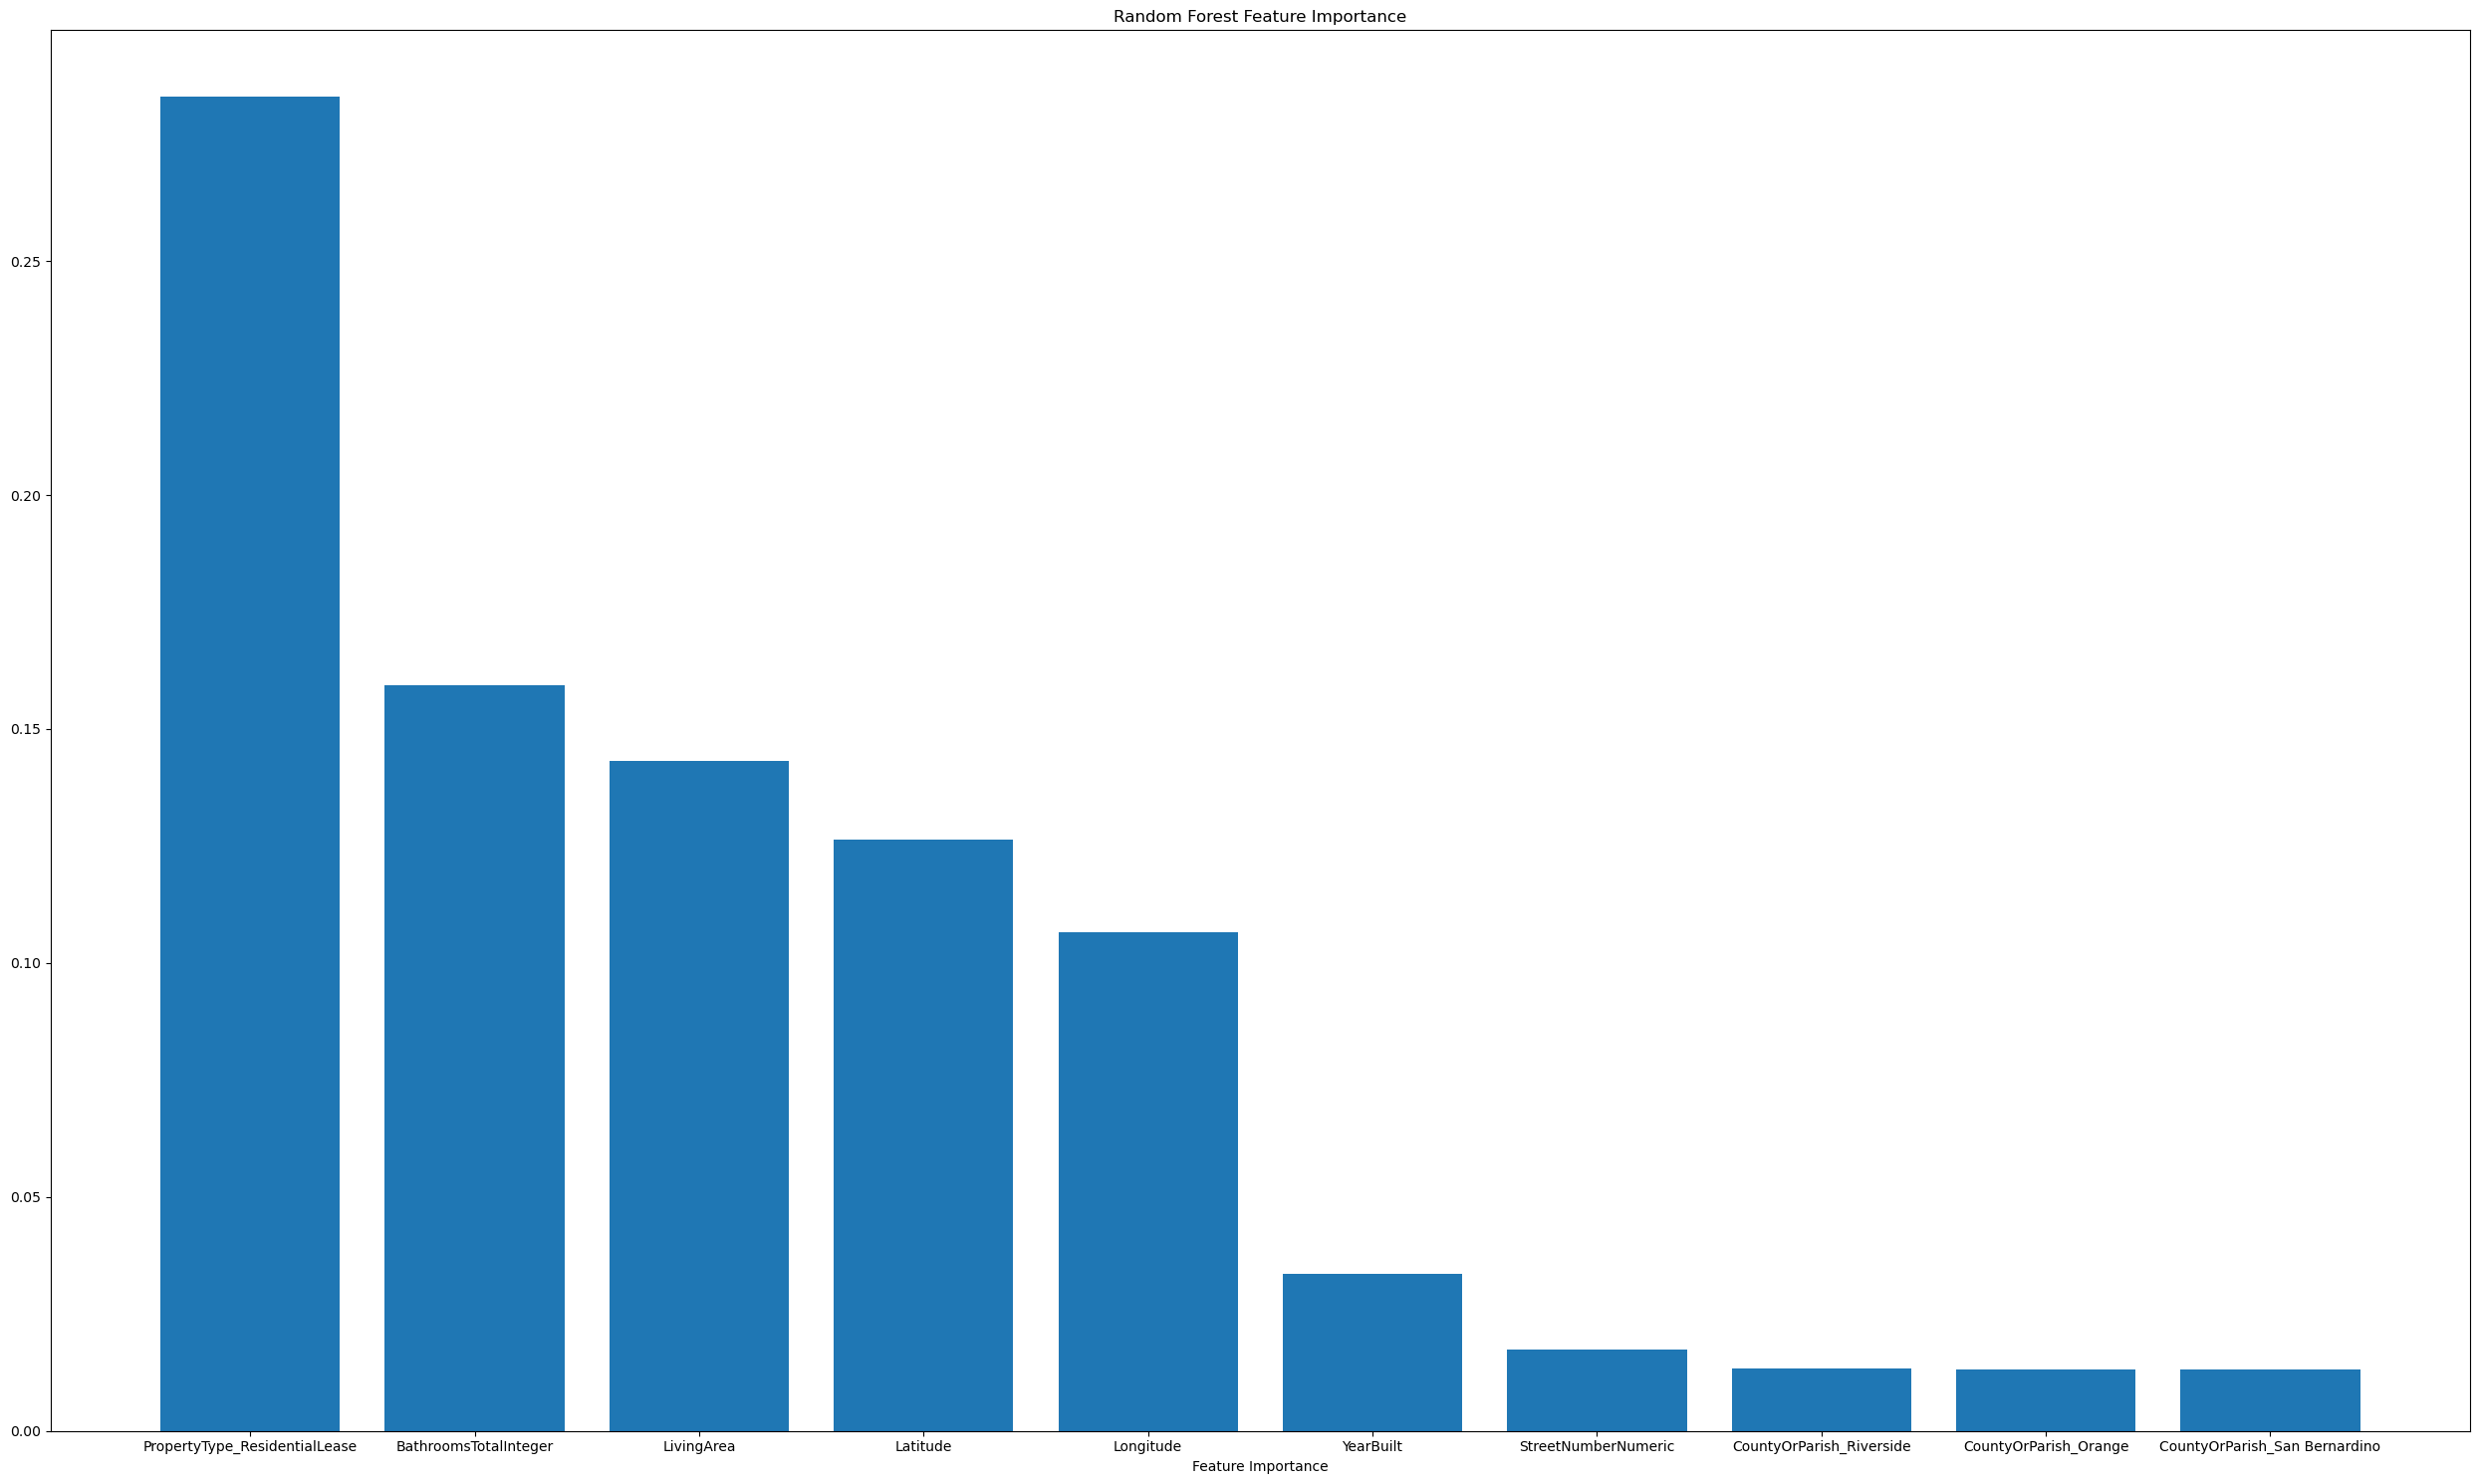

In [20]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# 4. Rolling-Origin Backtesting


In [21]:
result_roll=[]

for X in range(4,13):
    months = sorted(data_clean["date_ym"].unique())
    data_train=data_clean[data_clean['date_ym'].isin(months[:X])]
    data_test=data_clean[data_clean['date_ym']==months[X]]
    # remove some outliers from train dataset
    lower=data_train["ClosePrice"].quantile(0.005)
    upper=data_train["ClosePrice"].quantile(0.995)
    data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]
    # categorical features
    cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode"]
    for col in cols:
       top10 = data_train[col].value_counts().nlargest(10).index
       data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
       data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

    
    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"ElasticNet Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = DecisionTreeRegressor(max_depth=10,random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------DecisionTree regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Decision Tree Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Random Forest regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Random Forest Regressor",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    

C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

--------------ElasticNet regression-------------
MdAPE: 33.86%
MAPE : 19.1305
R²   : 0.0079
MAE  : 390191.8382
MSE  : 63609047972378.5312
RMSE : 7975528.0686
--------------DecisionTree regression-------------
MdAPE: 17.77%
MAPE : 0.9360
R²   : 0.0098
MAE  : 282326.5646
MSE  : 63486707008332.6875
RMSE : 7967854.6051
--------------Random Forest regression-------------
MdAPE: 9.22%
MAPE : 0.6655
R²   : 0.0111
MAE  : 205820.5102
MSE  : 63404985428727.2031
RMSE : 7962724.7490


C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

--------------ElasticNet regression-------------
MdAPE: 34.67%
MAPE : 21.1502
R²   : 0.0102
MAE  : 408296.3037
MSE  : 46781902137428.8828
RMSE : 6839729.6831
--------------DecisionTree regression-------------
MdAPE: 17.70%
MAPE : 0.5317
R²   : 0.0140
MAE  : 290674.1193
MSE  : 46601591997710.0859
RMSE : 6826535.8710
--------------Random Forest regression-------------
MdAPE: 8.95%
MAPE : 0.4069
R²   : 0.0157
MAE  : 214008.2443
MSE  : 46521227203107.8047
RMSE : 6820647.1250


C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

...

--------------ElasticNet regression-------------
MdAPE: 35.17%
MAPE : 18.0172
R²   : 0.0077
MAE  : 435308.1561
MSE  : 67442585370444.1641
RMSE : 8212343.4762
--------------DecisionTree regression-------------
MdAPE: 17.24%
MAPE : 0.4351
R²   : 0.0097
MAE  : 309883.7963
MSE  : 67310639039159.0078
RMSE : 8204306.1278
--------------Random Forest regression-------------
MdAPE: 8.35%
MAPE : 0.3056
R²   : 0.0111
MAE  : 225900.8373
MSE  : 67213605680270.1328
RMSE : 8198390.4323


C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

--------------ElasticNet regression-------------
MdAPE: 35.21%
MAPE : 17.1901
R²   : 0.2924
MAE  : 348429.9740
MSE  : 1234010104194.8152
RMSE : 1110860.0741
--------------DecisionTree regression-------------
MdAPE: 17.57%
MAPE : 0.5158
R²   : 0.3899
MAE  : 223519.9911
MSE  : 1064015906627.5304
RMSE : 1031511.4670
--------------Random Forest regression-------------
MdAPE: 7.98%
MAPE : 0.3541
R²   : 0.4429
MAE  : 139431.2214
MSE  : 971460198464.1525
RMSE : 985626.8049


C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_8232\3092561760.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

--------------ElasticNet regression-------------
MdAPE: 35.26%
MAPE : 16.1644
R²   : -1.5176
MAE  : 360622.0982
MSE  : 2965056660381.7534
RMSE : 1721933.9884
--------------DecisionTree regression-------------
MdAPE: 18.01%
MAPE : 0.4024
R²   : 0.5877
MAE  : 233732.2800
MSE  : 485542301632.7786
RMSE : 696808.6550
--------------Random Forest regression-------------
MdAPE: 8.07%
MAPE : 0.2924
R²   : 0.6941
MAE  : 137719.1256
MSE  : 360231315196.1251
RMSE : 600192.7317


# 5. Record the result

In [22]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.to_csv("prediction_result_4.csv", index=True)
pd.DataFrame(results).to_csv("model_result_4.csv",index=True)
pd.DataFrame(result_roll).to_csv("model_result_roll_4.csv",index=True)

# 6. Report the result of comparsion between models

## Model Comparison

### ElasticNet Regression (Baseline)

ElasticNet Regression was used as the baseline model. It achieved a test **R² of -1.5174** and a **MdAPE of 35.29%**, indicating poor predictive performance. The negative R² suggests that the model performs worse than simply predicting the average house price. Since ElasticNet assumes a linear relationship between features and the target variable, it is unable to capture the complex nonlinear relationships commonly found in housing price prediction.

**Strengths**
- Simple and computationally efficient.
- Easy to interpret.
- Performs feature selection through L1 regularization while reducing overfitting with L2 regularization.

**Weaknesses**
- Assumes a linear relationship between features and house prices.
- Cannot effectively model nonlinear interactions.
- Highest MdAPE and lowest R² among all tested models.

---

### Decision Tree Regressor

The Decision Tree Regressor achieved a test **R² of 0.5935** with a **MdAPE of 17.68%**, representing a substantial improvement over the baseline model. Compared with ElasticNet, the median prediction error was reduced by approximately half, demonstrating that nonlinear decision boundaries are much more suitable for modeling housing prices.

The model achieved a training **R² of approximately 0.798**, which is higher than its test performance and suggests some degree of overfitting.

**Strengths**
- Captures nonlinear relationships automatically.
- Easy to understand and visualize.
- Significantly improves both R² and MdAPE compared with the baseline model.

**Weaknesses**
- Can overfit the training data if the tree becomes too deep.
- Prediction stability depends on the tree structure and hyperparameter settings.

---

### Random Forest Regressor

The Random Forest Regressor achieved the best overall performance, with a test **R² of 0.6900** and the lowest **MdAPE of 8.22%**. Compared with the Decision Tree, Random Forest further improved the model's explanatory power while reducing the median percentage prediction error by more than 50%. By averaging predictions from multiple decision trees, Random Forest produces more accurate and stable predictions.

The training **R² of approximately 0.988** is substantially higher than the test R², indicating that some overfitting is still present despite its strong test performance.

**Strengths**
- Highest test R² among all tested models.
- Lowest MdAPE, indicating the most accurate median prediction.
- Handles complex nonlinear relationships effectively.
- More robust and stable than a single decision tree.

**Weaknesses**
- Longer training time.
- More difficult to interpret than an individual decision tree.
- The gap between training and test R² indicates some overfitting.

---

### Overall Comparison

The overall model performance is summarized below:

| Model | R² | MdAPE |
|------|------:|------:|
| ElasticNet Regression | **-1.5174** | **35.29%** |
| Decision Tree Regressor | **0.5935** | **17.68%** |
| Random Forest Regressor | **0.6900** | **8.22%** |

Using the most recent six months of housing transaction data, the tree-based models consistently outperformed the linear baseline. While **R²** measures how well each model explains the variation in housing prices, **MdAPE** reflects the typical percentage prediction error and is more robust to the skewed distribution of housing prices. Random Forest achieved the highest test R² and the lowest MdAPE, indicating that it explains the largest proportion of price variation while also providing the most accurate typical predictions. Although the gap between its training and test R² suggests some overfitting, Random Forest still provides the strongest test performance among the evaluated models. Therefore, **Random Forest is selected as the most suitable model for this housing price prediction task.**

# 7. Feature engineer

Example of sample features you can engineer: bed/bath ratio, age of property in years

In [70]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188845 entries, 0 to 188844
Data columns (total 37 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ViewYN                           188845 non-null  int64  
 1   PoolPrivateYN                    188845 non-null  int64  
 2   ClosePrice                       188845 non-null  float64
 3   Latitude                         188845 non-null  float64
 4   Longitude                        188845 non-null  float64
 5   LivingArea                       188845 non-null  float64
 6   MLSAreaMajor                     188845 non-null  object 
 7   CountyOrParish                   188845 non-null  object 
 8   ParkingTotal                     188845 non-null  float64
 9   PropertySubType                  188845 non-null  object 
 10  LotSizeAcres                     188845 non-null  float64
 11  YearBuilt                        188845 non-null  float64
 12  St

In [71]:
data_clean_2=data_clean.copy()
data_clean_2["BedBathRatio"]=data_clean_2["BedBathRatio"] = np.where(data_clean_2["BathroomsTotalInteger"] == 0,0, data_clean_2["BedroomsTotal"] / data_clean_2["BathroomsTotalInteger"])
data_clean_2["Years"]=2026-data_clean_2["YearBuilt"]
# data_clean_2["LivingAreaRatio"] = np.where(data_clean_2["LotSizeSquareFeet"] == 0,0, data_clean_2["LivingArea"] /data_clean_2["LotSizeSquareFeet"])
# data_clean_2["AreaPerBedroom"] =np.where(data_clean_2["BedroomsTotal"] == 0,0, data_clean_2["LivingArea"] /data_clean_2["BedroomsTotal"])
# data_clean_2["AreaPerBathroom"] =np.where(data_clean_2["BathroomsTotalInteger"] == 0,0,data_clean_2["LivingArea"] /data_clean_2["BathroomsTotalInteger"]) 

In [72]:
data_clean_2.head()

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease,BedBathRatio,Years
0,1,0,890000.0,34.264692,-117.221040,3000.0,287A - Arrowhead Woods,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,0,0,1,0,0,1.0,5.0
1,0,0,6995.0,34.261268,-119.272458,1386.0,VC23 - Ventura Beach S. of Ventura River to S.C.,Ventura,2.0,SingleFamilyResidence,...,0,0,0,0,0,0,0,1,1.5,70.0
2,1,0,865000.0,33.906058,-117.777782,1442.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,0,0,0,0,1,0,0,1.5,41.0
3,0,0,875000.0,37.705919,-122.059421,1086.0,Unknown,Alameda,4.0,SingleFamilyResidence,...,0,0,0,0,0,1,0,0,3.0,73.0
4,0,0,769645.0,37.986319,-122.001549,1608.0,Unknown,Contra Costa,0.0,SingleFamilyResidence,...,0,0,0,0,0,1,0,0,1.5,73.0


In [73]:
data_clean_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188845 entries, 0 to 188844
Data columns (total 39 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ViewYN                           188845 non-null  int64  
 1   PoolPrivateYN                    188845 non-null  int64  
 2   ClosePrice                       188845 non-null  float64
 3   Latitude                         188845 non-null  float64
 4   Longitude                        188845 non-null  float64
 5   LivingArea                       188845 non-null  float64
 6   MLSAreaMajor                     188845 non-null  object 
 7   CountyOrParish                   188845 non-null  object 
 8   ParkingTotal                     188845 non-null  float64
 9   PropertySubType                  188845 non-null  object 
 10  LotSizeAcres                     188845 non-null  float64
 11  YearBuilt                        188845 non-null  float64
 12  St

# 8. Adding more detailed geographic layer using school districts

## 8.1 load the geographic

In [74]:
import geopandas as gpd
districts=gpd.read_file('DistrictAreas2526_-284845464123469011.geojson')
districts_filter=districts[districts["DistrictType"]=="Unified"]
districts_filter

,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,932,2025-26,0641580,5772694,57726940000000,Yolo,Washington Unified,Unified,PK,12,...,1,0.0,1242,15.1,3796,46.2,27.524200,13,"13 - City, Small","POLYGON ((-13538678.161 4660316.003, -13538674..."
927,933,2025-26,0642930,5772702,57727020000000,Yolo,Winters Joint Unified,Unified,PK,12,...,105,5.0,335,16.0,1185,56.7,126.903010,31,"31 - Town, Fringe","POLYGON ((-13578206.161 4668467.848, -13577796..."
928,934,2025-26,0643080,5772710,57727100000000,Yolo,Woodland Joint Unified,Unified,PK,12,...,296,3.2,1704,18.3,6827,73.4,309.459071,23,"23 - Suburban, Small","POLYGON ((-13580837.089 4696906.449, -13580814..."
930,936,2025-26,0624090,5872736,58727360000000,Yuba,Marysville Joint Unified,Unified,PK,12,...,47,0.4,1673,16.0,7648,73.2,462.497708,22,"22 - Suburban, Midsize","POLYGON ((-13540500.026 4756982.131, -13540491..."


In [75]:
districts_filter.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 345 entries, 0 to 934
Data columns (total 51 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID          345 non-null    int32   
 1   Year              345 non-null    object  
 2   FedID             345 non-null    object  
 3   CDCode            345 non-null    object  
 4   CDSCode           345 non-null    object  
 5   CountyName        345 non-null    object  
 6   DistrictName      345 non-null    object  
 7   DistrictType      345 non-null    object  
 8   GradeLow          345 non-null    object  
 9   GradeHigh         345 non-null    object  
 10  GradeLowCensus    345 non-null    object  
 11  GradeHighCensus   345 non-null    object  
 12  AssistStatus      345 non-null    object  
 13  UpdateNotes       133 non-null    object  
 14  EnrollTotal       345 non-null    int32   
 15  EnrollCharter     345 non-null    int32   
 16  EnrollNonCharter  

In [76]:
#points from the data
points=gpd.GeoDataFrame(data_clean_2,geometry=gpd.points_from_xy(data_clean_2["Longitude"],data_clean_2["Latitude"]), crs="EPSG:4326")

In [77]:
districts_filter = districts_filter.to_crs("EPSG:4326")

In [78]:
points=gpd.sjoin(points,districts_filter,how="left",predicate="within")#Left Join

In [79]:
points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 188845 entries, 0 to 188844
Data columns (total 91 columns):
 #   Column                           Non-Null Count   Dtype   
---  ------                           --------------   -----   
 0   ViewYN                           188845 non-null  int64   
 1   PoolPrivateYN                    188845 non-null  int64   
 2   ClosePrice                       188845 non-null  float64 
 3   Latitude                         188845 non-null  float64 
 4   Longitude                        188845 non-null  float64 
 5   LivingArea                       188845 non-null  float64 
 6   MLSAreaMajor                     188845 non-null  object  
 7   CountyOrParish                   188845 non-null  object  
 8   ParkingTotal                     188845 non-null  float64 
 9   PropertySubType                  188845 non-null  object  
 10  LotSizeAcres                     188845 non-null  float64 
 11  YearBuilt                        188845 non-

# 9. Comparsion after feature engineer and add a geo feature

drop unrelated feature

In [80]:
points.drop(columns=["index_right","OBJECTID","FedID"])

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,HOMpct,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc
0,1,0,890000.0,34.264692,-117.221040,3000.0,287A - Arrowhead Woods,San Bernardino,2.0,SingleFamilyResidence,...,1.3,0.0,0.0,447.0,15.5,1778.0,61.5,113.055142,31,"31 - Town, Fringe"
1,0,0,6995.0,34.261268,-119.272458,1386.0,VC23 - Ventura Beach S. of Ventura River to S.C.,Ventura,2.0,SingleFamilyResidence,...,2.7,21.0,0.1,2225.0,15.9,8197.0,58.4,193.520728,12,"12 - City, Midsize"
2,1,0,865000.0,33.906058,-117.777782,1442.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,13.9,15.0,0.1,3161.0,14.2,10492.0,47.1,39.259300,21,"21 - Suburban, Large"
3,0,0,875000.0,37.705919,-122.059421,1086.0,Unknown,Alameda,4.0,SingleFamilyResidence,...,0.9,2.0,0.0,1186.0,12.2,3784.0,39.0,66.885261,21,"21 - Suburban, Large"
4,0,0,769645.0,37.986319,-122.001549,1608.0,Unknown,Contra Costa,0.0,SingleFamilyResidence,...,0.7,12.0,0.0,4357.0,14.4,16246.0,53.6,124.663808,21,"21 - Suburban, Large"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188840,1,0,865000.0,34.242304,-116.802871,2166.0,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,10.3,4.0,0.2,330.0,15.3,1495.0,69.2,236.300524,32,"32 - Town, Distant"
188841,1,1,4000.0,33.701018,-116.292460,2957.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,2.3,131.0,0.5,3446.0,13.6,19324.0,76.5,768.026072,21,"21 - Suburban, Large"
188842,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,10.3,4.0,0.2,330.0,15.3,1495.0,69.2,236.300524,32,"32 - Town, Distant"
188843,0,0,595000.0,37.824500,-122.281570,2502.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,4.6,27.0,0.1,7646.0,17.6,34974.0,80.4,53.162702,11,"11 - City, Large"


handle missing value

In [81]:
points=points.dropna()

### 9.1 Test train split

In [82]:
X=12 # past 2 month
months = sorted(points["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=points[points['date_ym'].isin(months[-X:-1])]
data_test=points[points['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

2025-07-01    5882
2026-04-01    5822
2026-05-01    5768
2025-08-01    5743
2025-10-01    5731
2026-03-01    5715
2025-09-01    5577
2025-12-01    5132
2025-11-01    4771
2026-02-01    4523
2026-01-01    4153
Name: date_ym, dtype: int64
2026-06-01    6044
Name: date_ym, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 58817 entries, 15195 to 172328
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           58817 non-null  int64   
 1   PoolPrivateYN                    58817 non-null  int64   
 2   ClosePrice                       58817 non-null  float64 
 3   Latitude                         58817 non-null  float64 
 4   Longitude                        58817 non-null  float64 
 5   LivingArea                       58817 non-null  float64 
 6   MLSAreaMajor                     58817 non-null  object  
 7   CountyOrParish        

delete unrealted features

In [83]:
data_train["CountyName"].value_counts()

Los Angeles        20044
Riverside          10726
Orange             10353
San Bernardino      9280
Alameda             3618
San Luis Obispo     1382
Butte               1267
Santa Clara          271
Fresno               249
Kern                 210
Madera               177
Mendocino            176
Solano               170
Ventura              134
Mariposa             126
Santa Barbara        111
Lake                  92
Stanislaus            74
San Joaquin           70
Sacramento            68
Napa                  48
Tulare                31
Santa Cruz            25
Merced                23
Plumas                20
Marin                 12
Calaveras             10
Sutter                 8
El Dorado              7
Imperial               7
Sonoma                 6
Lassen                 4
Mono                   4
Monterey               4
San Benito             3
Colusa                 3
Siskiyou               2
Sierra                 1
Inyo                   1
Name: CountyName, dtype: 

In [84]:
data_train["LocaleDesc"].value_counts()

11 - City, Large          24168
21 - Suburban, Large      17043
12 - City, Midsize         7716
22 - Suburban, Midsize     2331
13 - City, Small           1926
42 - Rural, Distant        1492
31 - Town, Fringe          1122
41 - Rural, Fringe         1087
32 - Town, Distant         1086
43 - Rural, Remote          314
33 - Town, Remote           307
23 - Suburban, Small        225
Name: LocaleDesc, dtype: int64

In [85]:
# remove some outliers from train dataset
lower=data_train["ClosePrice"].quantile(0.005)
upper=data_train["ClosePrice"].quantile(0.995)
data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

In [86]:
data_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 58233 entries, 15195 to 172328
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           58233 non-null  int64   
 1   PoolPrivateYN                    58233 non-null  int64   
 2   ClosePrice                       58233 non-null  float64 
 3   Latitude                         58233 non-null  float64 
 4   Longitude                        58233 non-null  float64 
 5   LivingArea                       58233 non-null  float64 
 6   MLSAreaMajor                     58233 non-null  object  
 7   CountyOrParish                   58233 non-null  object  
 8   ParkingTotal                     58233 non-null  float64 
 9   PropertySubType                  58233 non-null  object  
 10  LotSizeAcres                     58233 non-null  float64 
 11  YearBuilt                        58233 non-null  float

convert data type

In [87]:
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# keep consistently
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [88]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

In [89]:
result_after=[]

In [90]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 58233 entries, 15195 to 172328
Columns: 160 entries, ViewYN to LocaleDesc_Other
dtypes: float64(51), int64(15), uint8(94)
memory usage: 35.0 MB


## 9.2 ElasticNet - Baseline model

In [91]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.953e+15, tolerance: 3.470e+12
  model = cd_fast.enet_coordinate_descent(


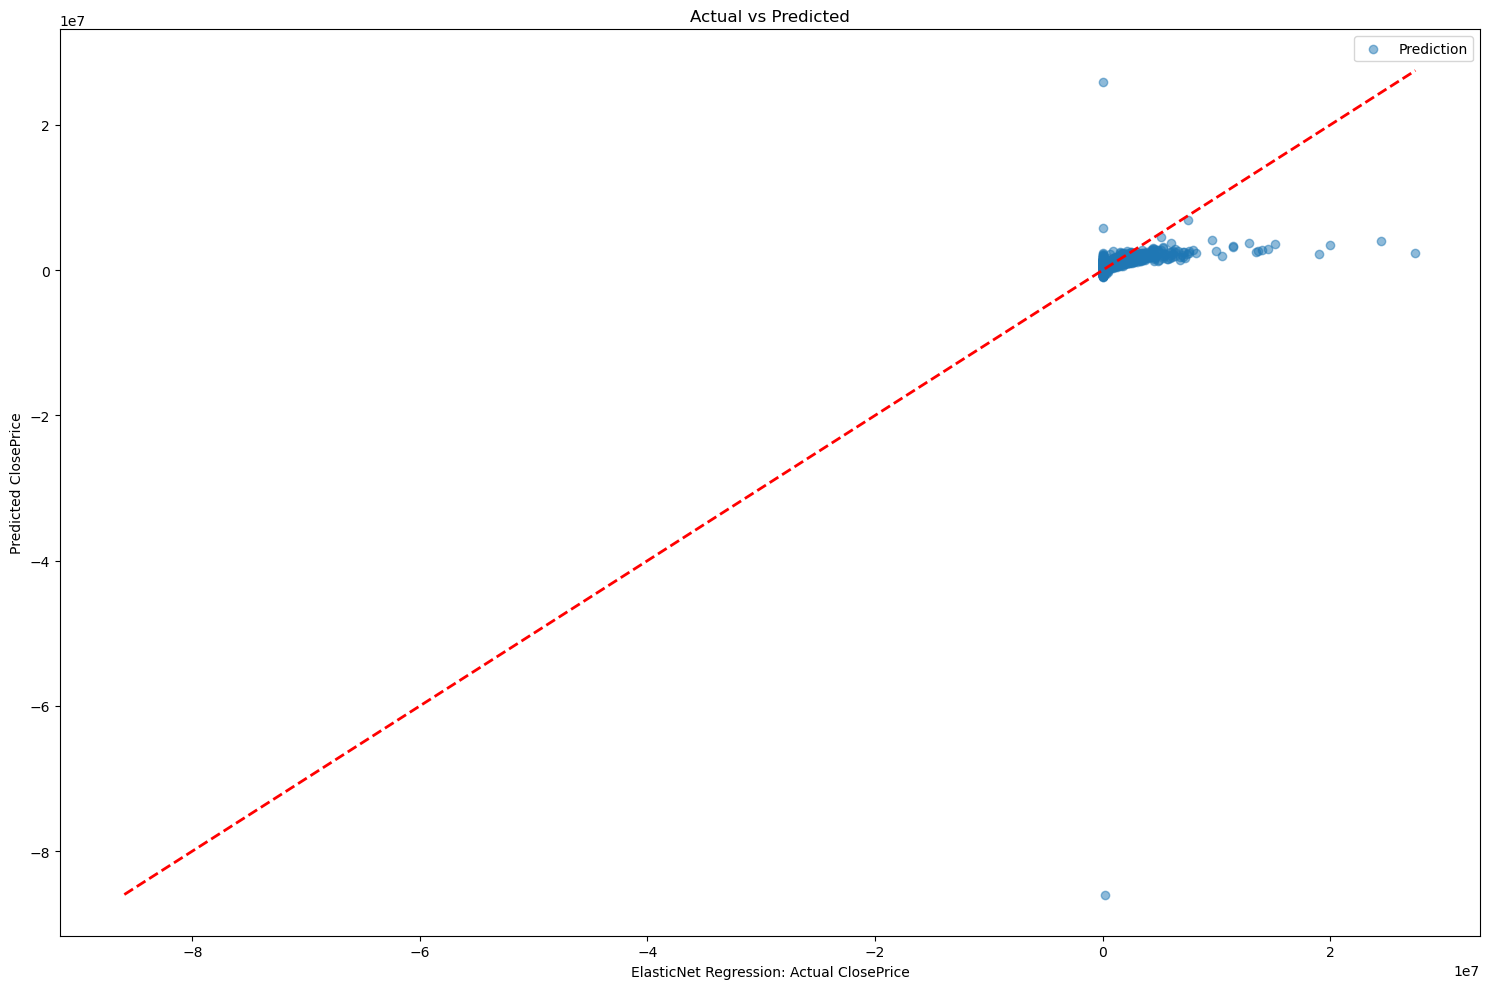

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("ElasticNet Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [93]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

result_after.append({
    "model":"ElasticNet - Baseline model",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})


MdAPE: 32.93%
MAPE : 21.7937
R²   : -0.5648
MAE  : 347199.8244
MSE  : 2064798236125.2278
RMSE : 1436940.5820


## 9.3 Decision Tree Regressor

In [94]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=10,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

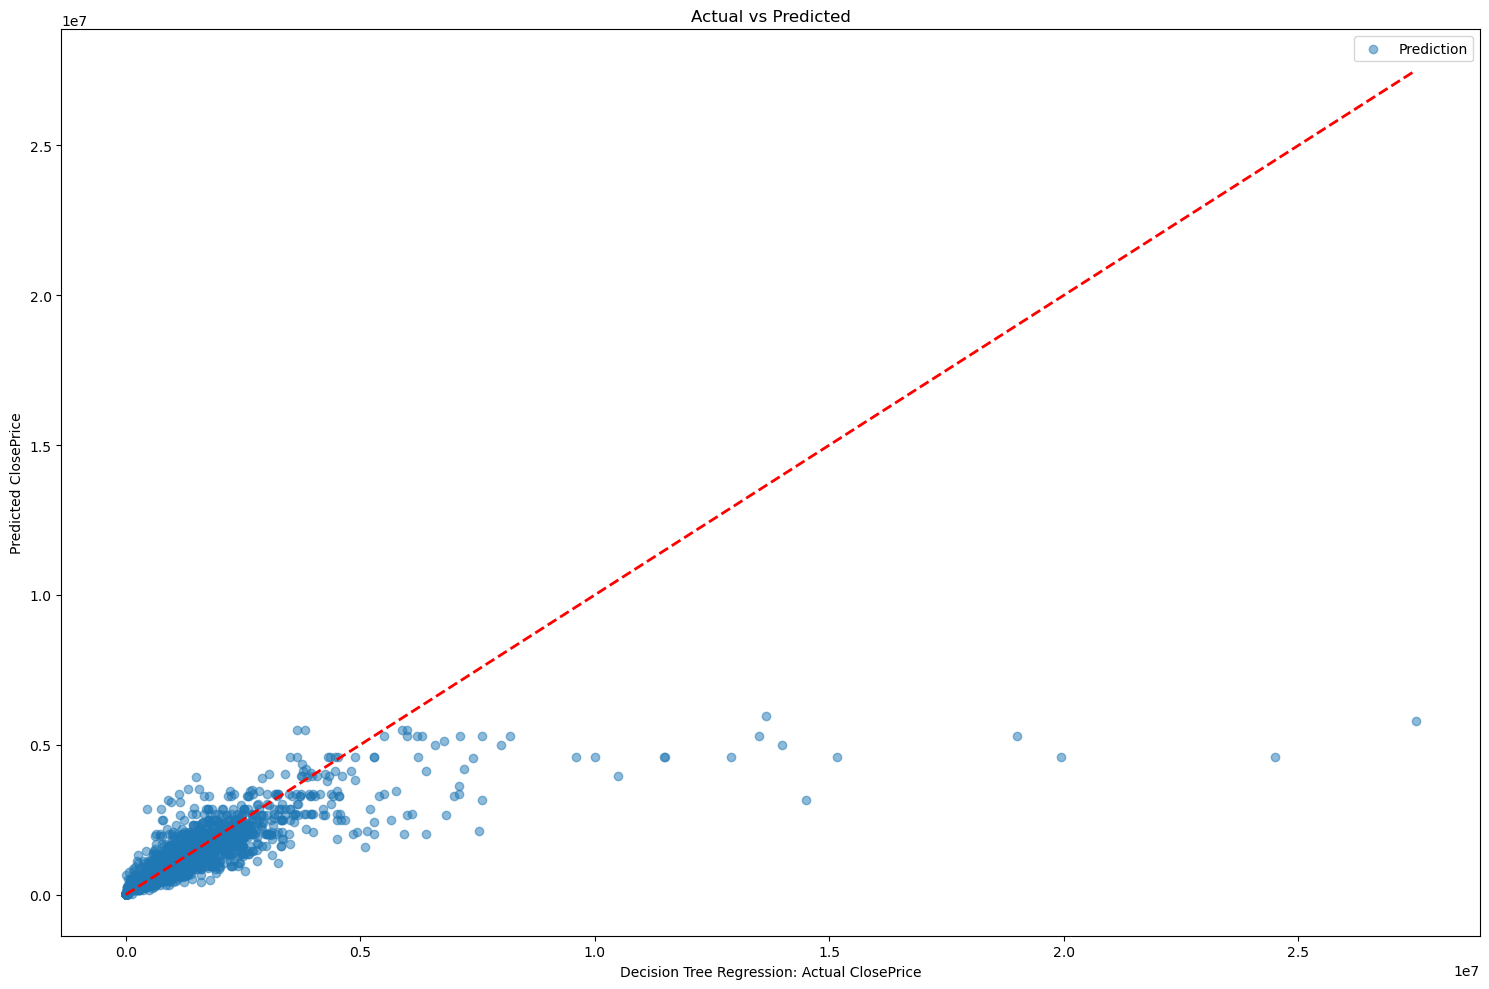

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Decision Tree Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [96]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

result_after.append({
    "model":"Decision Tree Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 14.66%
MAPE : 0.4398
R²   : 0.6446
MAE  : 194431.0412
MSE  : 468984833016.9718
RMSE : 684824.6732


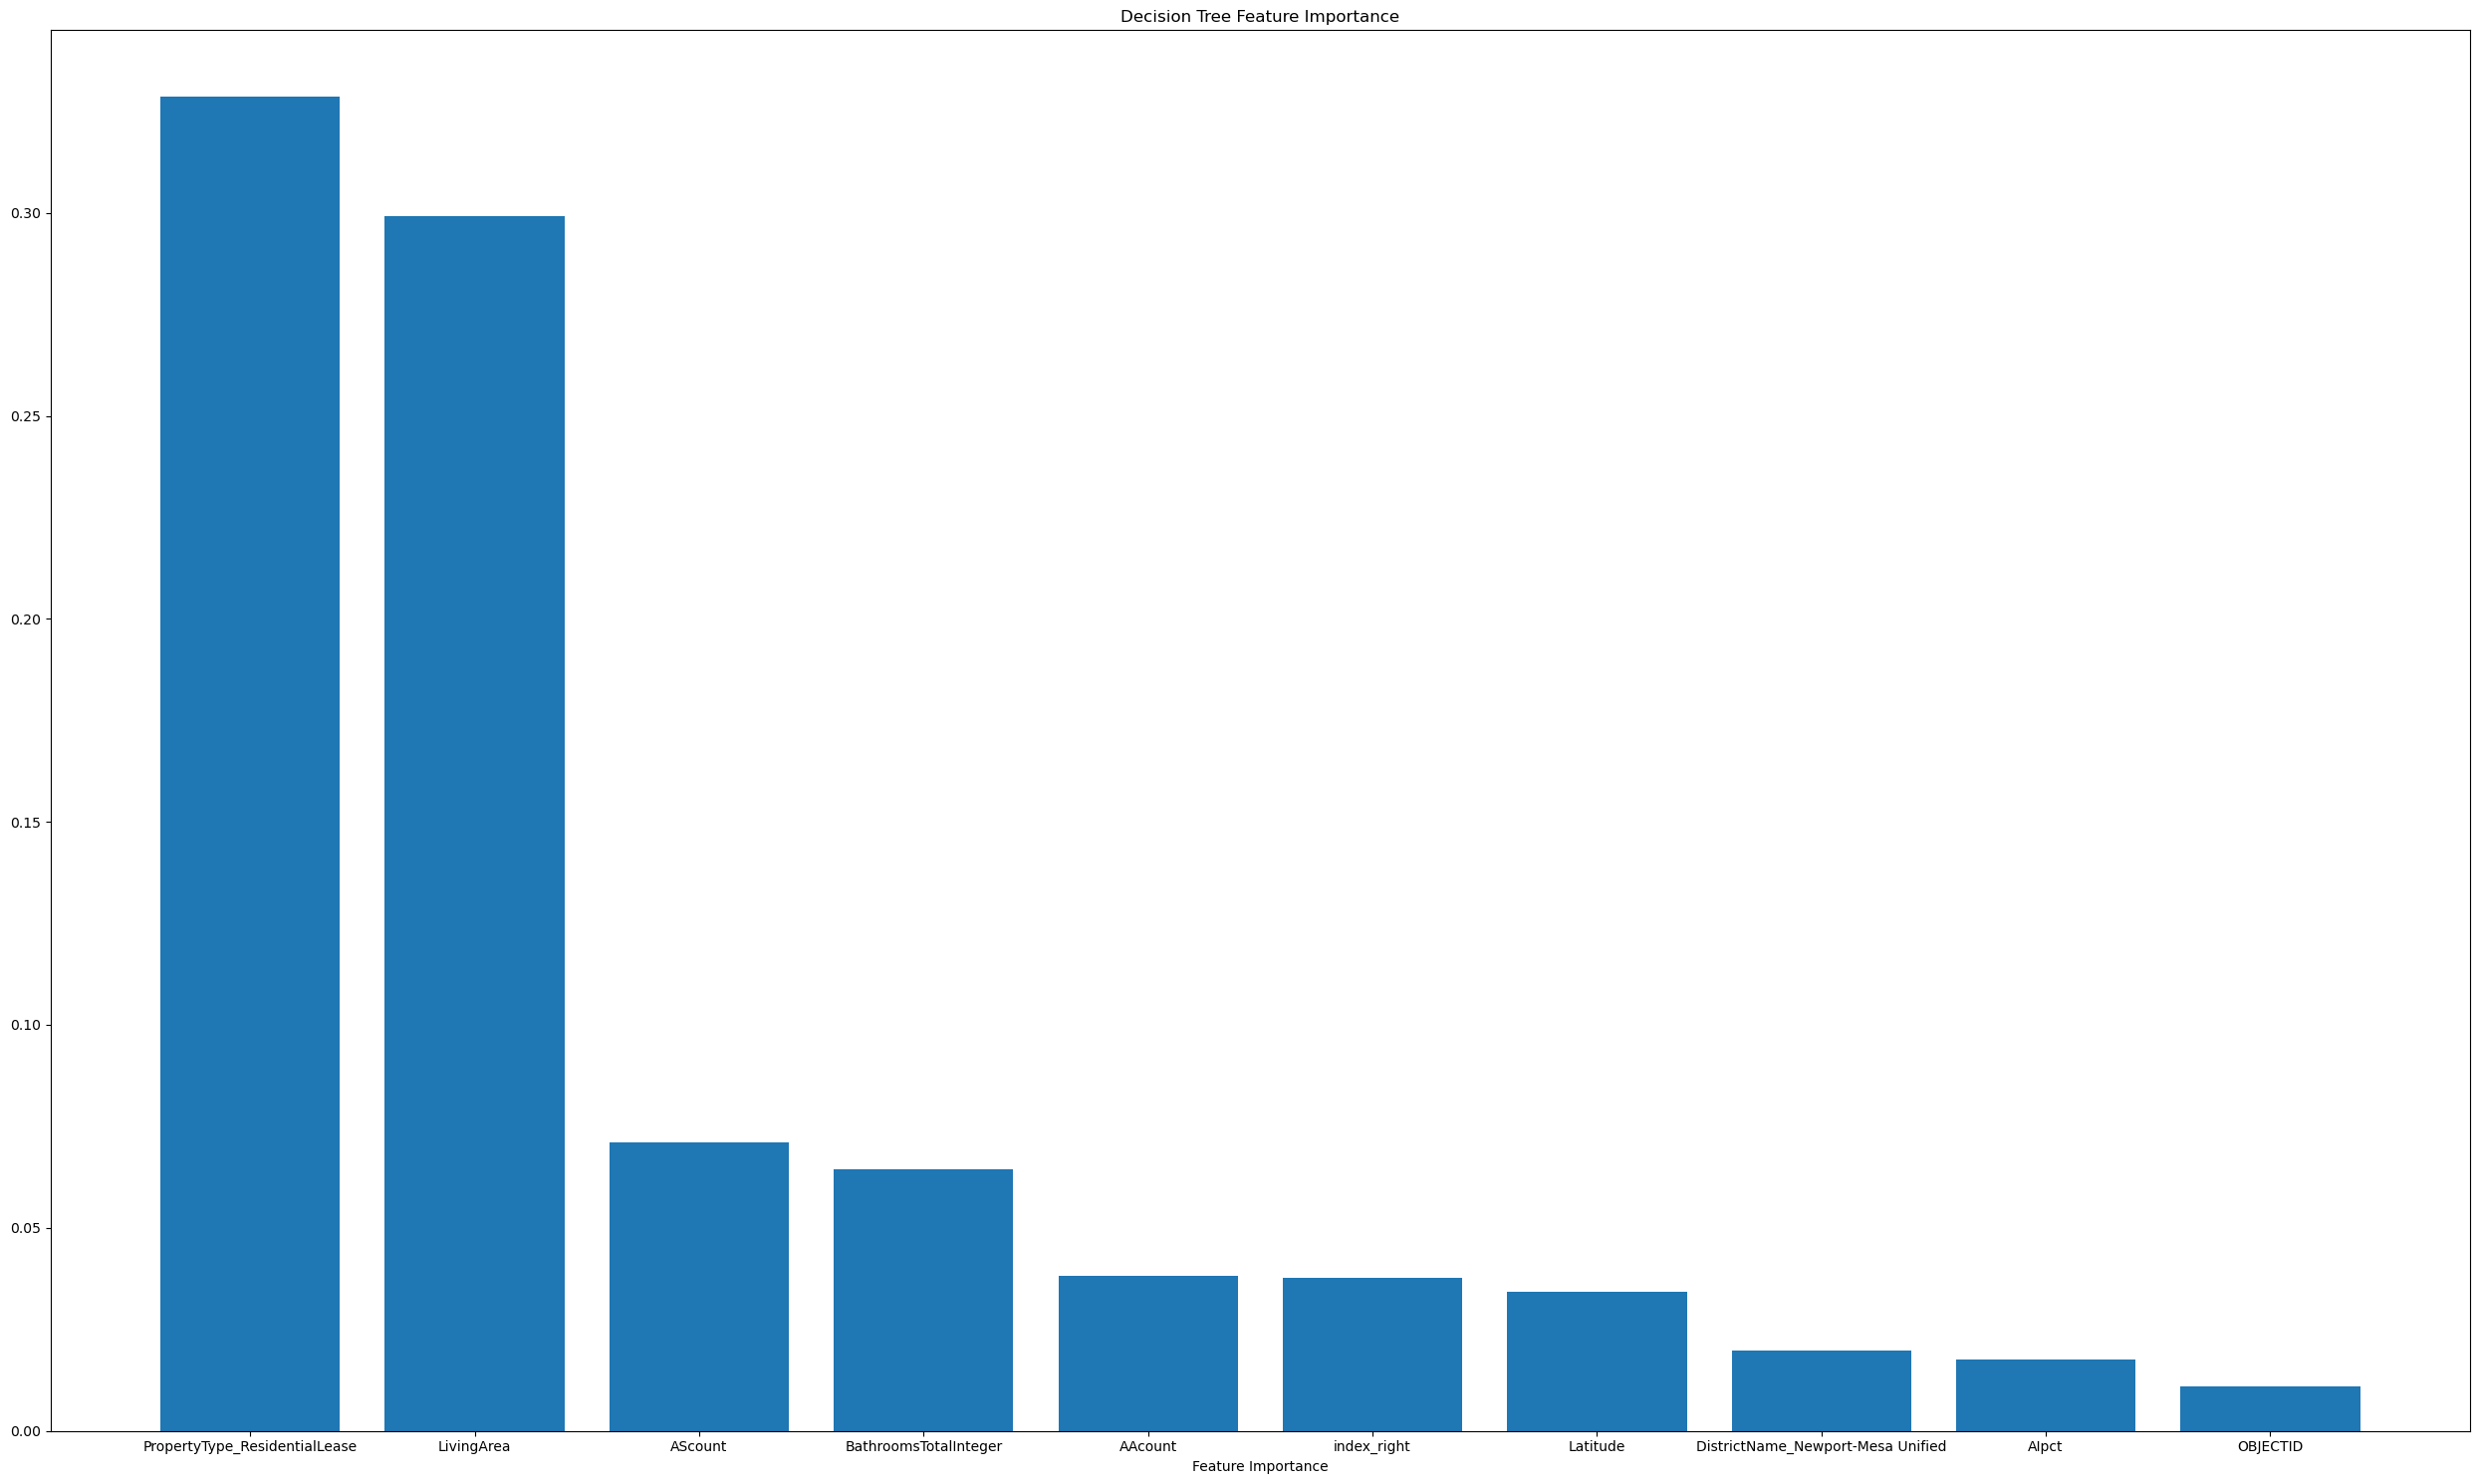

In [97]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

## 9.4 Random Forest Regressor

In [98]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

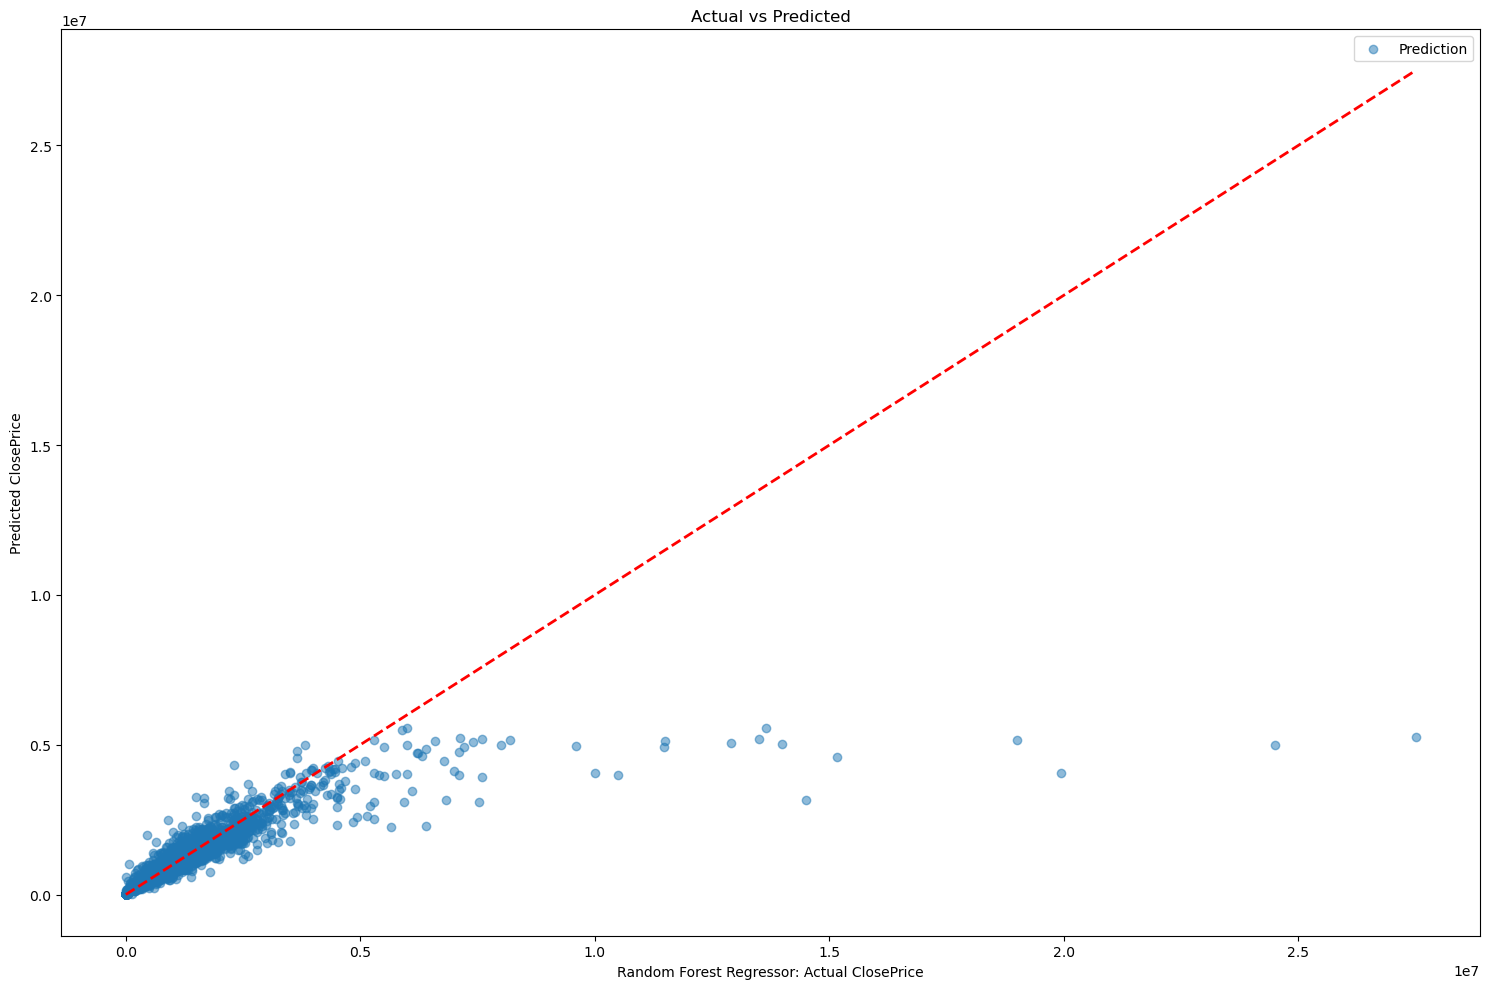

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [100]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

result_after.append({
    "model":"Random Forest",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 9.13%
MAPE : 0.3477
R²   : 0.6889
MAE  : 138977.8248
MSE  : 410503540580.8824
RMSE : 640705.5022


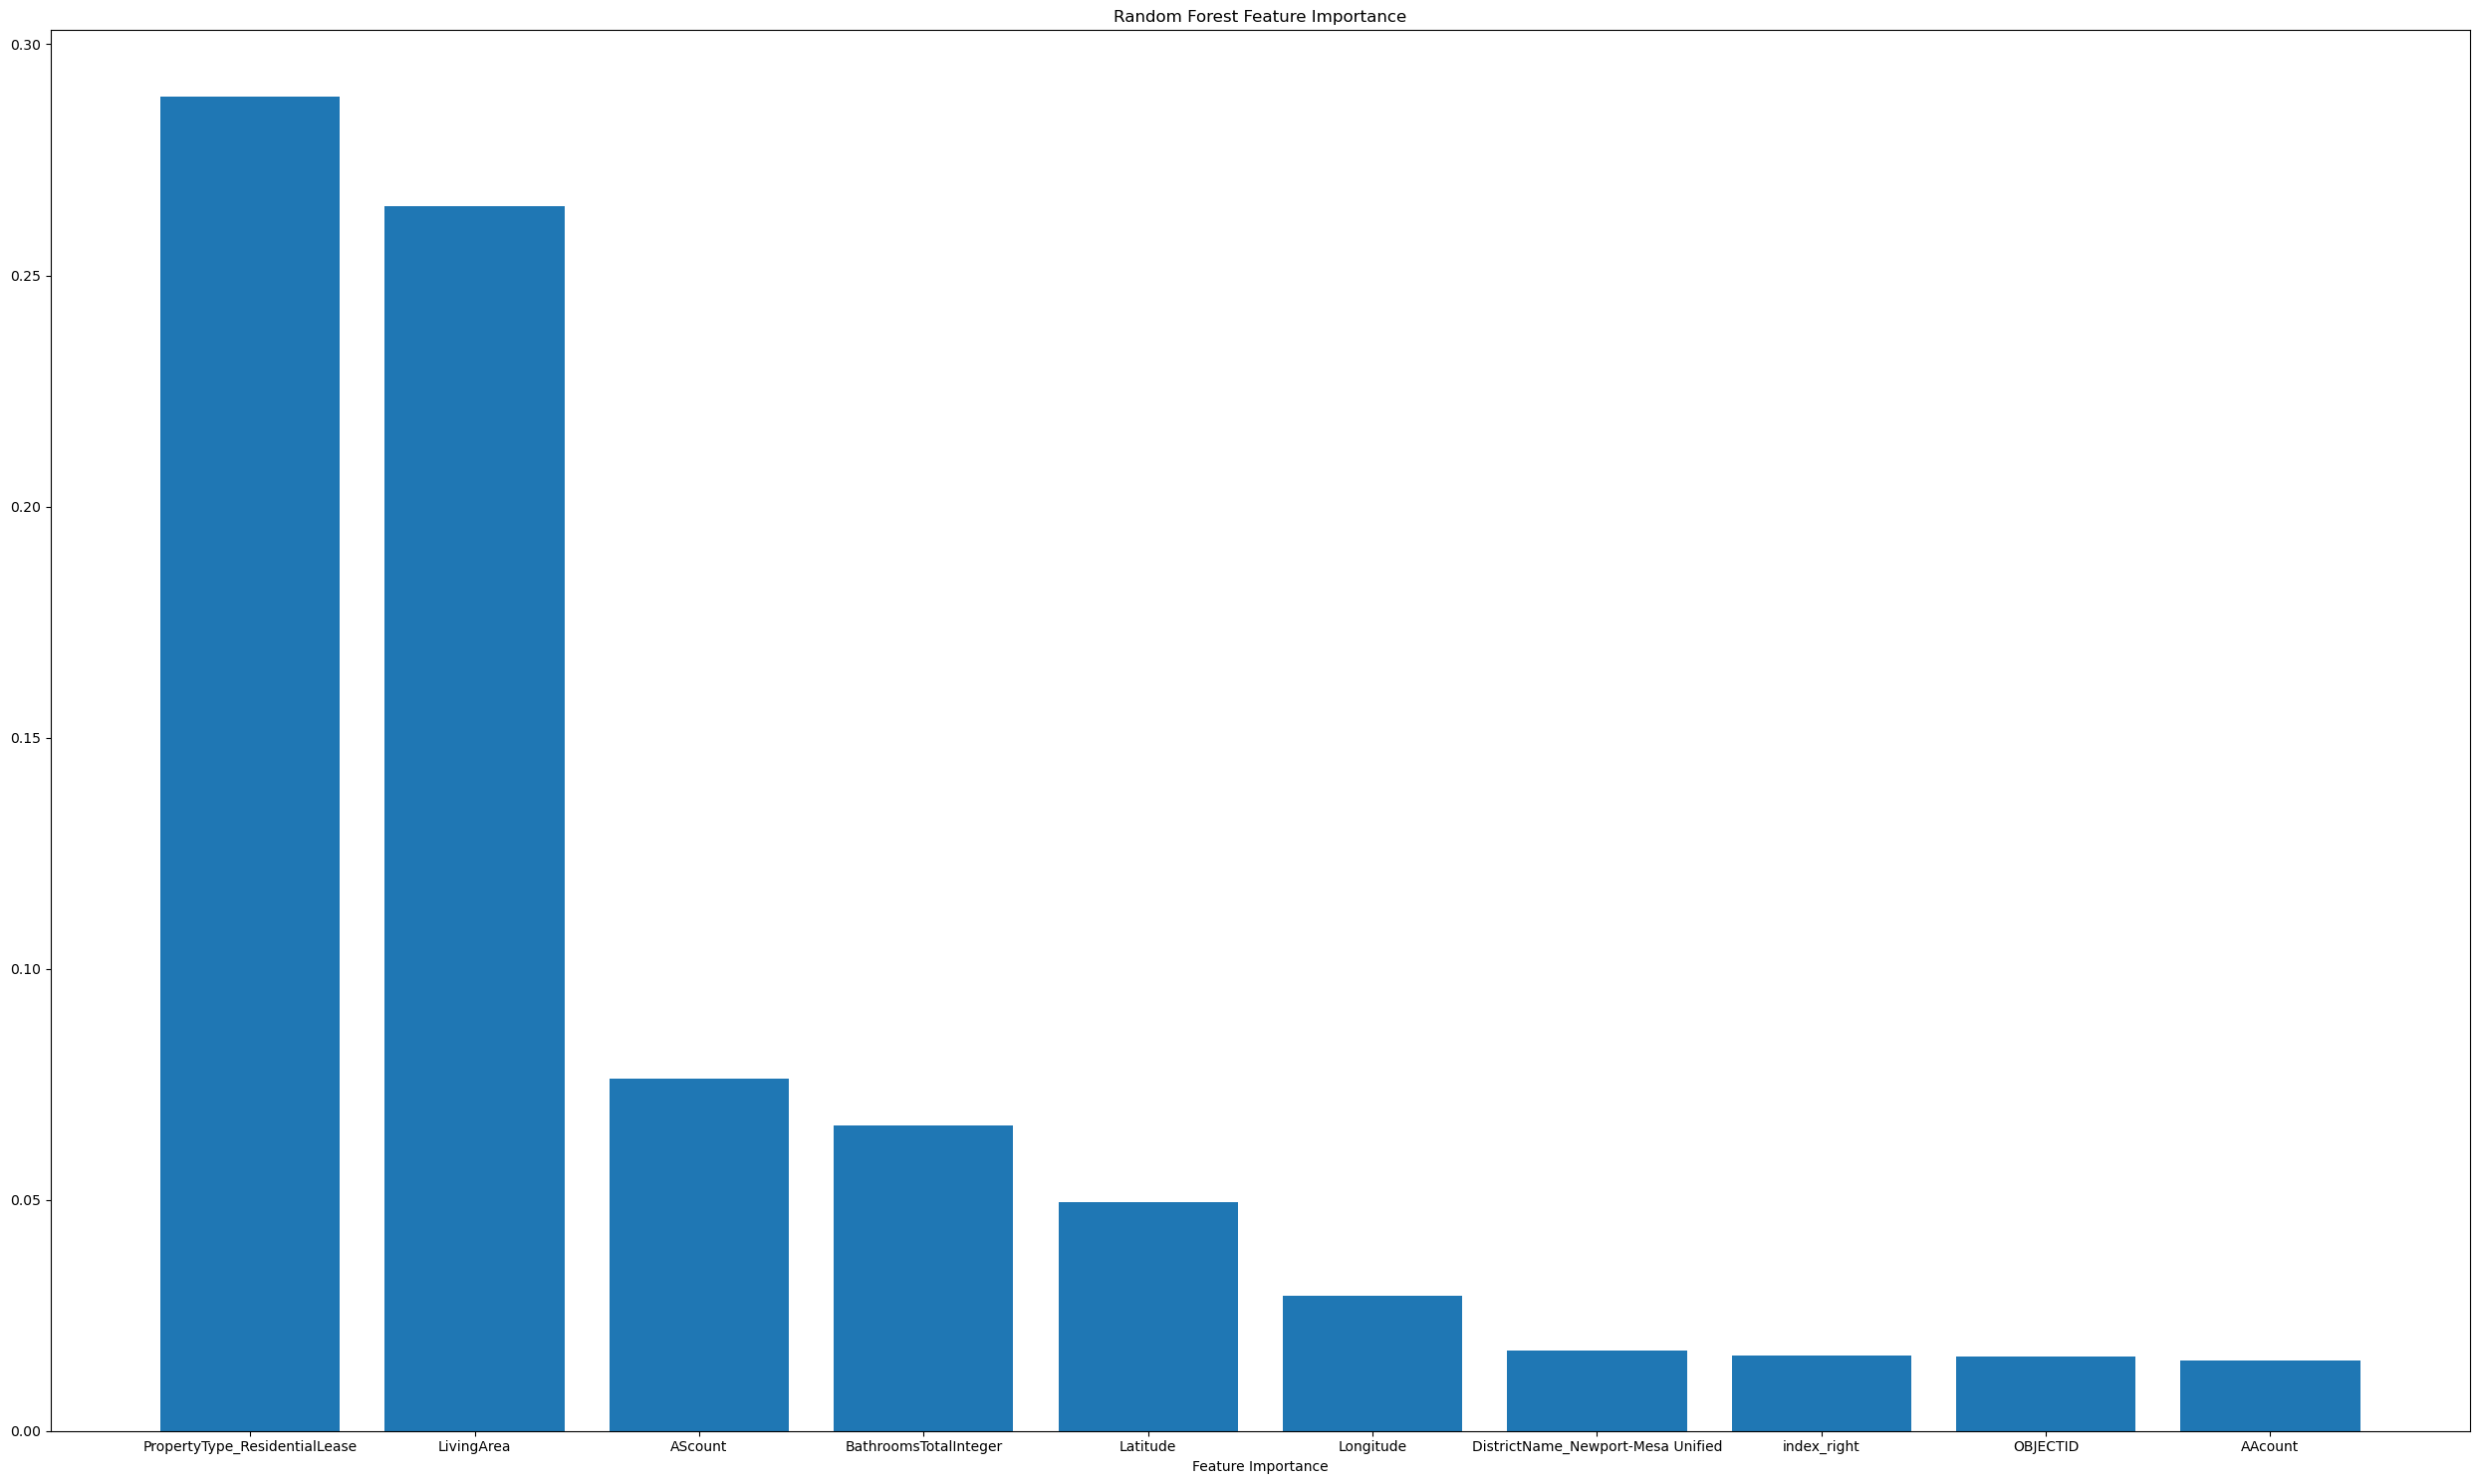

In [101]:
# Feature importance
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 9.5 Rolling-Origin Backtesting

In [102]:
result_roll_after=[]

for X in range(4,13):
    months = sorted(points["date_ym"].unique())
    data_train=points[points['date_ym'].isin(months[:X])]
    data_test=points[points['date_ym']==months[X]]
    # remove some outliers from train dataset
    lower=data_train["ClosePrice"].quantile(0.005)
    upper=data_train["ClosePrice"].quantile(0.995)
    data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

    cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
    for col in cols:
        top10 = data_train[col].value_counts().nlargest(10).index
        data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
        data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

    
    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"ElasticNet Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = DecisionTreeRegressor(max_depth=10,random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------DecisionTree regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"Decision Tree Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Random Forest regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"Random Forest Regressor",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 31.14%
MAPE : 63.4490
R²   : 0.5051
MAE  : 302701.8536
MSE  : 527909816128.1909
RMSE : 726574.0266
--------------DecisionTree regression-------------
MdAPE: 15.15%
MAPE : 1.8695
R²   : 0.6675
MAE  : 183722.8020
MSE  : 354717264837.6232
RMSE : 595581.4511
--------------Random Forest regression-------------
MdAPE: 9.80%
MAPE : 1.3538
R²   : 0.7197
MAE  : 135389.5928
MSE  : 299010077606.5417
RMSE : 546818.1394


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 33.71%
MAPE : 22.0902
R²   : 0.0623
MAE  : 354282.3224
MSE  : 8787502310938.4561
RMSE : 2964372.1613
--------------DecisionTree regression-------------
MdAPE: 15.01%
MAPE : 0.2924
R²   : 0.0850
MAE  : 222742.7118
MSE  : 8575009770551.3496
RMSE : 2928311.7612
--------------Random Forest regression-------------
MdAPE: 9.44%
MAPE : 0.2721
R²   : 0.0956
MAE  : 175942.8611
MSE  : 8475419897741.4492
RMSE : 2911257.4427


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

...

--------------ElasticNet regression-------------
MdAPE: 32.35%
MAPE : 24.1749
R²   : 0.4816
MAE  : 314770.2325
MSE  : 574977001756.0526
RMSE : 758272.3797
--------------DecisionTree regression-------------
MdAPE: 15.16%
MAPE : 0.2373
R²   : 0.6634
MAE  : 182397.1800
MSE  : 373274609937.4620
RMSE : 610962.0364
--------------Random Forest regression-------------
MdAPE: 9.20%
MAPE : 0.1739
R²   : 0.7259
MAE  : 128248.3262
MSE  : 304016349297.3475
RMSE : 551376.7762


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 32.60%
MAPE : 24.3563
R²   : 0.5382
MAE  : 315315.4895
MSE  : 468478242066.7606
RMSE : 684454.7042
--------------DecisionTree regression-------------
MdAPE: 15.03%
MAPE : 0.2790
R²   : 0.7188
MAE  : 177646.1511
MSE  : 285211103092.9857
RMSE : 534051.5922
--------------Random Forest regression-------------
MdAPE: 8.86%
MAPE : 0.1892
R²   : 0.7746
MAE  : 126650.5408
MSE  : 228608046783.8093
RMSE : 478129.7384


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 33.04%
MAPE : 21.7750
R²   : -0.6787
MAE  : 347976.0298
MSE  : 2215066392525.9106
RMSE : 1488309.9115
--------------DecisionTree regression-------------
MdAPE: 15.06%
MAPE : 0.4382
R²   : 0.6297
MAE  : 191595.1901
MSE  : 488587875168.9917
RMSE : 698990.6116
--------------Random Forest regression-------------
MdAPE: 8.90%
MAPE : 0.3489
R²   : 0.6892
MAE  : 138750.4667
MSE  : 410082281836.5114
RMSE : 640376.6718


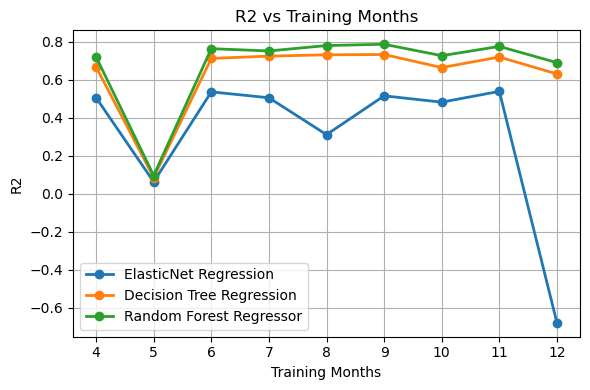

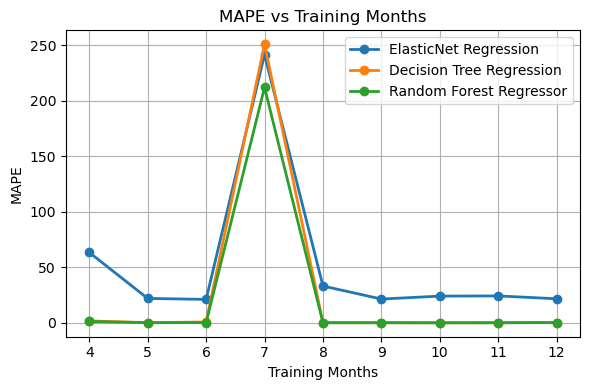

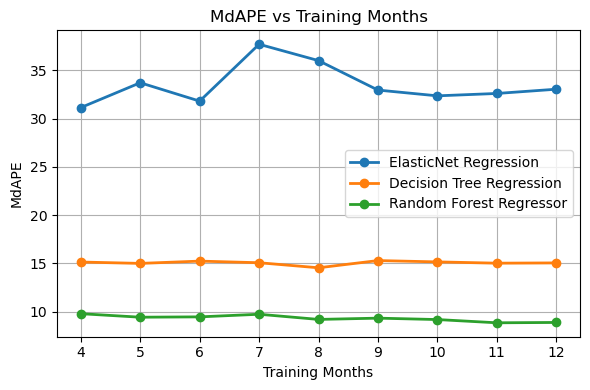

In [103]:
#plot
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(result_roll_after)
models = df["model"].unique()

metrics = ["R2", "MAPE", "MdAPE"]

for metric in metrics:
    plt.figure(figsize=(6,4))

    for model in models:
        temp = df[df["model"] == model].sort_values("train-test-X")
        plt.plot(
            temp["train-test-X"],
            temp[metric],
            marker="o",
            linewidth=2,
            label=model
        )

    plt.xlabel("Training Months")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Training Months")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [104]:
# Record the result
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
result.to_csv("prediction_result_6.csv", index=True)
pd.DataFrame(result_after).to_csv("model_result_6.csv",index=True)
pd.DataFrame(result_roll_after).to_csv("model_result_roll_6.csv",index=True)    


# 10. Result

The engineered features improved the performance of all models, indicating that they capture useful information beyond the original variables and enhance the models' predictive ability.